ESRGAN from scratch : Single image Super-Resolution in PytORCH

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms.functional import resize as tv_resize
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


* ESRGAN generator (RRDB-based)

RRDB : Residual-in-Residual Dense Blocks (RRDB).

In [ ]:
class RRDB(nn.Module):
  def __init__(self, nf=64): # Removed gc, using nf consistently
    super().__init__()
    self.conv1 = nn.Conv2d(nf, nf, 3, 1, 1)
    self.conv2 = nn.Conv2d(nf, nf, 3, 1, 1)
    self.conv3 = nn.Conv2d(nf, nf, 3, 1, 1)
    self.lrelu = nn.LeakyReLU(0.2, inplace=True)

  def forward(self, x):
    out = self.lrelu(self.conv1(x))
    out = self.lrelu(self.conv2(out))
    out = self.conv3(out)
    return x + 0.2 * out #Residual connection with small scaling

class ESRGANGenerator(nn.Module):
  def __init__(self, nf=64, nb=23, upscale=4, in_nc=3, nout_nc=3):
    super().__init__()
    self.upscale = upscale

    self.conv_first = nn.Conv2d(in_nc, nf, 3, 1, 1)

    self.body = nn.Sequential(
        *[RRDB(nf=nf) for _ in range(nb)]
    )
    self.conv_after_body = nn.Conv2d(nf, nf, 3, 1, 1)

    #Sub-pixel upscaling (pixel-shuffle)
    self.upsampler = nn.Sequential(
        nn.Conv2d(nf, nf * (upscale**2), 3, 1, 1),
        nn.PixelShuffle(upscale),
        nn.Conv2d(nf, nf, 3, 1, 1),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Conv2d(nf, nout_nc, 3, 1, 1), # Changed out_nc to nout_nc
    )

  def forward(self, x):
    x = self.conv_first(x)
    residual = x
    x = self.body(x)
    x = self.conv_after_body(x)
    x = x + residual
    x = self.upsampler(x)
    return x

#Define the Discriminator ( ESRGAN-style patch-GAN)

In [ ]:
class ESRGANDiscriminator(nn.Module):
  def __init__(self, in_nc=3, nf=64):
    super().__init__()
    def block(in_feat, out_feat, normalize=True):
      layers = [nn.Conv2d(in_feat, out_feat, 3, 1, 1, bias=False)]
      if normalize:
        layers.append(nn.BatchNorm2d(out_feat))
      layers.append(nn.LeakyReLU(0.2, inplace= True))
      return nn.Sequential(*layers) # Fix: Return nn.Sequential instead of a list

    self.model = nn.Sequential(
        block(in_nc, nf, normalize=False),
        block(nf, nf, normalize=False),
        block(nf, nf * 2),
        block(nf * 2, nf * 4), # Adjusted channel progression
        block(nf * 4, nf * 8), # Adjusted channel progression
        nn.Conv2d(nf * 8, 1, 3, 1, 1),
    )

  # Fix: Move forward method outside __init__
  def forward(self, x):
      return self.model(x)

making synthetic dataset : Toy Dataset
(generate LR from HR in memory)  

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


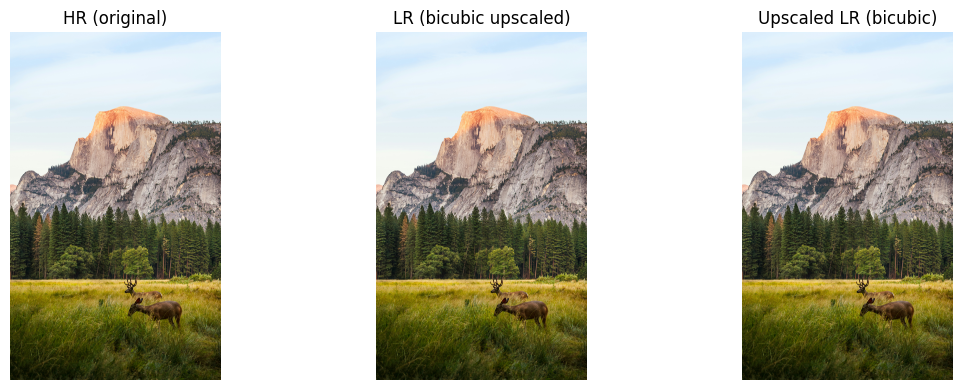

In [ ]:
#Load a sample image and treat it as HR
from google.colab import drive
from PIL import Image
import os
import matplotlib.pyplot as plt

drive.mount('/content/drive')

def load_sample_image(file_path):

  if not os.path.exists(file_path):
    raise FileNotFoundError(f"Image not found at: {file_path}")
  img = Image.open(file_path).convert("RGB")
  return img

#HR -> downscale (bicubic) to make LR
def make_lrx(hr, scale=4):
  w, h = hr.size
  w_lr = w //scale
  h_lr = h //scale
  lr = hr.resize((w_lr, h_lr), Image.BICUBIC)
  lr_up = lr.resize((w,h), Image.BICUBIC) #BICUBIC upsampled as  simple LR->hr
  return lr, lr_up

image_path = "/content/drive/MyDrive/image.jpg"

hr_img = load_sample_image(image_path)
lr_img, lr_up_img = make_lrx(hr_img, scale=4)

#Show them
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(hr_img)
ax[0].set_title("HR (original)")
ax[1].imshow(lr_up_img)
ax[1].set_title("LR (bicubic upscaled)")
ax[2].imshow(lr_img.resize(hr_img.size, Image.BICUBIC))
ax[2].set_title("Upscaled LR (bicubic)")
[axi.set_axis_off() for axi in ax]
plt.tight_layout()
plt.show()

simple dataset class and DataLoader

In [ ]:
class SuperResDataset(Dataset):
  def __init__(self, hr_img, scale=4, crop_size=64, n_samples=10): # Reduced crop_size to 64
    self.scale = scale
    self.crop_size = crop_size
    self.hr = hr_img
    self.n_samples = n_samples

  def __len__(self):
    return self.n_samples

  def __getitem__(self, idx):
    #Random crop HR
    w, h = self.hr.size
    x = np.random.randint(0, w - self.crop_size)
    y = np.random.randint(0, h - self.crop_size)
    hr_crop = self.hr.crop((x, y, x + self.crop_size, y + self.crop_size)) # Corrected line
    hr_tensor = transforms.ToTensor() (hr_crop)

    #Downscale then upsample to get LR
    w_lr = self.crop_size //self.scale
    h_lr = self.crop_size //self.scale
    lr = hr_crop.resize((w_lr, h_lr), Image.BICUBIC)
    lr = lr.resize((self.crop_size, self.crop_size), Image.BICUBIC)
    lr_tensor = transforms.ToTensor()(lr)

    return lr_tensor, hr_tensor

#Create dataset and loader
dataset = SuperResDataset(hr_img, scale=4, crop_size=64, n_samples=32) # Reduced crop_size to 64
loader = DataLoader(dataset, batch_size=1, shuffle=True) # Reduced batch_size to 1

Loss Functions and VGG features extractor : ESRGAN uses VGG based perceptual loss +adversarial loss; feature-base loss we are using a small vgg backbone.

In [ ]:
#a small vgg-like feature extractor.

class VGGFeatureExtractor(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 64, 3, 1, 1)
    self.conv2 = nn.Conv2d(64, 64, 3, 1, 1)
    self.conv3 = nn.Conv2d(64, 128, 3, 1, 1)
    self.relu = nn.LeakyReLU(0.2, inplace=True) # ADDED THIS LINE

  def forward(self, x):
    x = self.relu(self.conv1(x))
    x = self.relu(self.conv2(x))
    x = self.relu(self.conv3(x))
    return x # ADDED RETURN STATEMENT

feature_extractor = VGGFeatureExtractor().to(device)

#Define loss functions
def content_loss(hr_features, sr_features):
  return F.l1_loss(hr_features, sr_features)

#Discriminator hinge loss (simplified)
def discriminator_loss (real_pred, fake_fred):
  loss_real = torch.mean(F.relu(1.0 - real_pred))
  loss_fake = torch.mean(F.relu(1.0 + fake_fred))
  return loss_real + loss_fake

def generator_adv_loss (fake_pred):
  return torch.mean(fake_pred)

Build models and optimizers

In [ ]:
gen = ESRGANGenerator(nf=64, nb=8, upscale=4) #smaller for toy training
disc = ESRGANDiscriminator(nf=64)

gen = gen.to(device)
disc = disc.to(device)

opt_gen = optim.Adam(gen.parameters(), lr=1e-4, betas= (0.9, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=1e-4, betas= (0.9, 0.999))

Training Loop

In [ ]:
gen.train()
disc.train()

n_epochs = 50

for epoch in range(n_epochs):
  for i, (lr, hr) in enumerate(loader):
    lr = lr.to(device)
    hr = hr.to(device)

    #generator forward
    sr = gen(lr)

    #Discriminator loss
    real_pred = disc(hr)
    fake_pred = disc(sr.detach())
    loss_d = discriminator_loss(real_pred, fake_pred)

    opt_disc.zero_grad()
    loss_d.backward()
    opt_disc.step()


    #Generator / perceptual loss
    # Upscale hr to match the spatial dimensions of sr for feature extraction
    hr_upscaled = F.interpolate(hr, scale_factor=gen.upscale, mode='bicubic', align_corners=False)
    hr_feat = feature_extractor(hr_upscaled)
    sr_feat = feature_extractor(sr)
    loss_g_content = content_loss(hr_feat, sr_feat)

    # Calculate generator adversarial loss (FIXED: loss_g_adv was missing)
    fake_pred_for_gen = disc(sr) # Discriminator's prediction on the generated (fake) image for generator's loss
    loss_g_adv = generator_adv_loss(fake_pred_for_gen)

    loss_g = 0.005 * loss_g_adv + 1.0 * loss_g_content #toy weights

    opt_gen.zero_grad()
    loss_g.backward()
    opt_gen.step()

    if i % 2 == 0:
      print(
          f"Epoch {epoch+1}/{n_epochs} | G loss: {loss_g.item():.4f} | D loss: {loss_d.item():.4f}"
      )

Epoch 1/50 | G loss: 0.0176 | D loss: 1.8546
Epoch 1/50 | G loss: 0.0331 | D loss: 1.7037
Epoch 1/50 | G loss: 0.0005 | D loss: 1.8435
Epoch 1/50 | G loss: 0.0273 | D loss: 1.2040
Epoch 1/50 | G loss: 0.0062 | D loss: 1.7519
Epoch 1/50 | G loss: 0.0218 | D loss: 0.8658
Epoch 1/50 | G loss: 0.0091 | D loss: 1.4684
Epoch 1/50 | G loss: 0.0124 | D loss: 0.6242
Epoch 1/50 | G loss: 0.0009 | D loss: 1.2988
Epoch 1/50 | G loss: 0.0056 | D loss: 1.0188
Epoch 1/50 | G loss: 0.0084 | D loss: 0.3160
Epoch 1/50 | G loss: 0.0023 | D loss: 1.2924
Epoch 1/50 | G loss: 0.0030 | D loss: 0.2426
Epoch 1/50 | G loss: 0.0032 | D loss: 0.1270
Epoch 1/50 | G loss: 0.0028 | D loss: 0.0756
Epoch 1/50 | G loss: 0.0013 | D loss: 0.3587
Epoch 2/50 | G loss: 0.0006 | D loss: 0.0542
Epoch 2/50 | G loss: 0.0026 | D loss: 0.3599
Epoch 2/50 | G loss: 0.0018 | D loss: 0.0103
Epoch 2/50 | G loss: -0.0006 | D loss: 0.3318
Epoch 2/50 | G loss: 0.0006 | D loss: 0.4079
Epoch 2/50 | G loss: 0.0004 | D loss: 0.2765
Epoch 2/5

Inference and Visualization

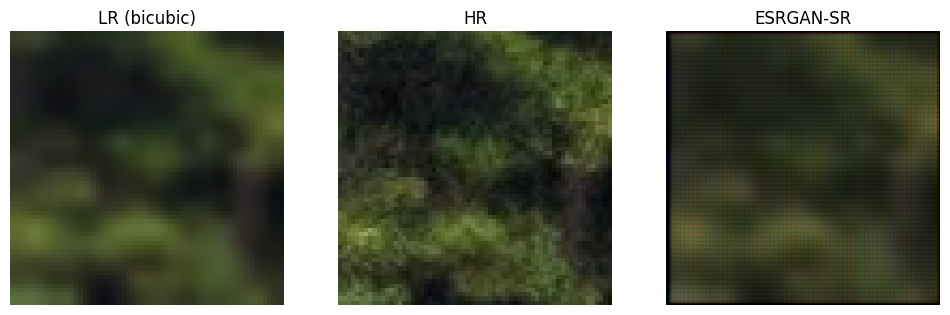

In [ ]:
gen.eval()
with torch.no_grad():
  #Take first LR image in loader
  lr, hr = next(iter(loader))
  lr = lr.to(device)
  sr = gen(lr)

  # Convert to numpy for display
  def tensor_to_pil(t):
    t = t.cpu()
    if t.dim() == 4:
      t = t[0]
    t = t.permute(1, 2, 0)
    t = t.clamp(0, 1)
    return Image.fromarray((t.numpy() * 255). astype(np.uint8))

  lr_img_show = tensor_to_pil(lr)
  hr_img_show = tensor_to_pil(hr)
  sr_img_show = tensor_to_pil(sr)

  fig, ax = plt.subplots(1, 3, figsize=(12, 4))
  ax[0].imshow(lr_img_show)
  ax[0].set_title("LR (bicubic)")
  ax[1].imshow(hr_img_show)
  ax[1].set_title("HR")
  ax[2].imshow(sr_img_show)
  ax[2].set_title("ESRGAN-SR")
  [axi.set_axis_off() for axi in ax]
  plt.show()

From these results, we can see that bicubic interpolation makes the image bigger but also blurry. The ESRGAN output tries to bring back more details and make the image look sharper, but in this case the result is still not perfect and has some noise. This means the model has learned the basic idea of super-resolution, but it still needs more training and better tuning to give cleaner results. Overall, ESRGAN is better than simple resizing because it can create more detailed images instead of just stretching pixels.